In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import os


In [2]:
ecg_3 = pd.read_csv('../raw_data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_database.csv')

In [3]:
ecg_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 21799 entries, 0 to 21798
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ecg_id                        21799 non-null  int64  
 1   patient_id                    21799 non-null  float64
 2   age                           21799 non-null  float64
 3   sex                           21799 non-null  int64  
 4   height                        6974 non-null   float64
 5   weight                        9421 non-null   float64
 6   nurse                         20326 non-null  float64
 7   site                          21782 non-null  float64
 8   device                        21799 non-null  str    
 9   recording_date                21799 non-null  str    
 10  report                        21799 non-null  str    
 11  scp_codes                     21799 non-null  str    
 12  heart_axis                    13331 non-null  str    
 13  infarction_s

In [8]:
ecg_3.isna().sum().sort_values(ascending=False)

electrodes_problems             21769
infarction_stadium2             21696
pacemaker                       21508
burst_noise                     21186
baseline_drift                  20201
extra_beats                     19850
static_noise                    18539
infarction_stadium1             16187
height                          14825
weight                          12378
validated_by                     9378
heart_axis                       8468
nurse                            1473
site                               17
recording_date                      0
device                              0
ecg_id                              0
patient_id                          0
age                                 0
sex                                 0
scp_codes                           0
report                              0
second_opinion                      0
initial_autogenerated_report        0
validated_by_human                  0
strat_fold                          0
filename_lr 

In [10]:
ecg_3.head()

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [34]:
ecg_3.iloc[0]

ecg_id                                                                 1
patient_id                                                       15709.0
age                                                                 56.0
sex                                                                    1
height                                                               NaN
weight                                                              63.0
nurse                                                                2.0
site                                                                 0.0
device                                                         CS-12   E
recording_date                                       1984-11-09 09:17:34
report                            sinusrhythmus periphere niederspannung
scp_codes                       {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
heart_axis                                                           NaN
infarction_stadium1                                

In [43]:
base_path = r"../raw_data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

def get_ecg_info(path):
    full_path = os.path.join(base_path, path)
    record = wfdb.rdrecord(full_path)

    signal_shape = record.p_signal.shape
    fs = record.fs
    channels = record.sig_name

    return signal_shape, fs, channels

In [ ]:
# ecg_3[['signal_shape','fs','channels']] = ecg_3['filename_lr'].apply(lambda x: pd.Series(get_ecg_info(x)))

In [48]:
ecg_3[['signal_shape','fs','channels']].to_csv('../processed_data/ecg_info.csv', index=False)

<Axes: >

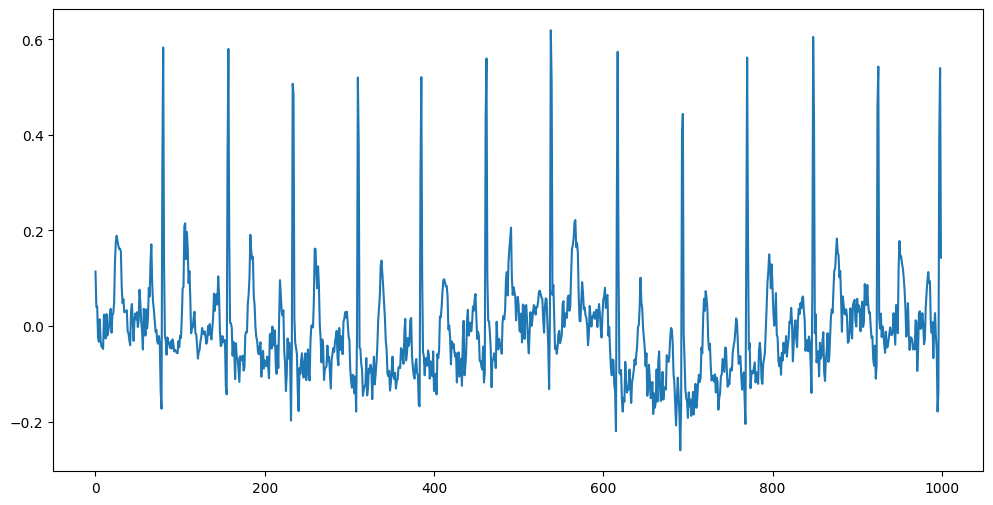

In [54]:
plt.figure(figsize=(12, 6))
sns.lineplot(signal[:,0])

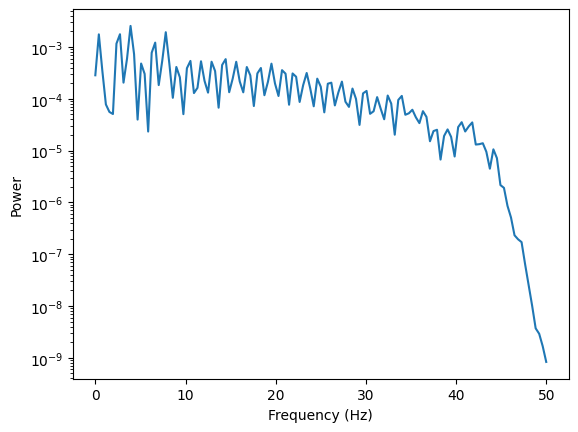

In [55]:
from scipy.signal import welch

f, Pxx = welch(signal[:,0], fs)

plt.semilogy(f, Pxx)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.show()